In [1]:
from agent_factory import create_agent
from generator_factory import create_generator


In [2]:
generator_name = "Periodic Trend Generator"
params =  {
        "start_value": 10.0,
        "amplitude": 2.0,
        "frequency": 5
    }
generator = create_generator(generator_name, params)

values = []
for i in range(10):    
    values.append(generator.generate_value(i))

print(f"Generated values from {generator_name}: {values}")

Generated values from Periodic Trend Generator: [np.float64(10.0), np.float64(8.082151450673724), np.float64(8.911957778221261), np.float64(11.300575680314234), np.float64(11.825890501455255), np.float64(9.735296499804454), np.float64(8.023936751814276), np.float64(9.143634661007699), np.float64(11.490226320958698), np.float64(11.701807049068236)]


In [3]:
agent_name = "Dynamic Mean Reversion Agent"
params = {
        "time_window": 5  # Example window size
    }
agent = create_agent(agent_name, params)

outcomes = []
bets = []
rewards = []

current_value = 5
for i in range(25):
    agent.observe(current_value)
    next_value = generator.generate_value(i)
    if next_value < current_value:
        outcome = 0
    else:
        outcome = 1
    
    bet = agent.place_bet()

    current_value = next_value

    outcomes.append(outcome)
    bets.append(bet)

    reward = 1 if outcome == bet else -1
    rewards.append(reward)
    print(f"Round {i+1}: Next Value: {outcome}, Bet: {bet}")

Round 1: Next Value: 1, Bet: 0
Round 2: Next Value: 0, Bet: 0
Round 3: Next Value: 1, Bet: 0
Round 4: Next Value: 1, Bet: 0
Round 5: Next Value: 0, Bet: 0
Round 6: Next Value: 0, Bet: 0
Round 7: Next Value: 0, Bet: 1
Round 8: Next Value: 1, Bet: 1
Round 9: Next Value: 1, Bet: 1
Round 10: Next Value: 0, Bet: 0
Round 11: Next Value: 0, Bet: 0
Round 12: Next Value: 0, Bet: 1
Round 13: Next Value: 1, Bet: 1
Round 14: Next Value: 1, Bet: 1
Round 15: Next Value: 0, Bet: 0
Round 16: Next Value: 0, Bet: 0
Round 17: Next Value: 0, Bet: 1
Round 18: Next Value: 1, Bet: 1
Round 19: Next Value: 1, Bet: 0
Round 20: Next Value: 0, Bet: 0
Round 21: Next Value: 0, Bet: 0
Round 22: Next Value: 0, Bet: 1
Round 23: Next Value: 1, Bet: 1
Round 24: Next Value: 1, Bet: 0
Round 25: Next Value: 0, Bet: 0


In [4]:
# print(f"Total Reward: {sum(rewards)}")
print(f"Total Reward: {sum(rewards)} points out of {len(rewards)} rounds")

Total Reward: 7 points out of 25 rounds


In [5]:
# testing the RealWorldAssetPriceGenerator

from custom_generators import RealWorldAssetPriceGenerator

generator = RealWorldAssetPriceGenerator("AAPl", "2020-01-01", "2021-01-01")

for i in range(10):
    value = generator.generate_value(i)
    print(f"Generated value on day {i}: {value}")

[INFO] Downloading data for AAPl from 2020-01-01 to 2021-01-01


c:\Users\JanderM\OneDrive - University of Twente\Documents\Github Repos\WP3_eXplainable_and_Fair_AI\IRP1\Code\predictability_betting_game\code\custom_generators.py:37: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start, end=self.end)
[*********************100%***********************]  1 of 1 completed

[INFO] Saved to cache at ..\data\real_world_asset_prices\AAPl_2020-01-01_2021-01-01.parquet
Generated value on day 0: 72.62083435058594
Generated value on day 1: 71.91481018066406
Generated value on day 2: 72.48786163330078
Generated value on day 3: 72.14693450927734
Generated value on day 4: 73.30751037597656
Generated value on day 5: 74.8646240234375
Generated value on day 6: 75.03387451171875
Generated value on day 7: 76.63692474365234
Generated value on day 8: 75.60206604003906
Generated value on day 9: 75.27806854248047


In [6]:
generator_name = "Real World Asset Price Generator"
params = {
    "ticker": "AAPL",
    "start": "1985-01-01",
    "end": "2025-01-01"
}
generator = create_generator(generator_name, params)

values = []
for i in range(10):    
    value = (generator.generate_value(i))
    print(f"Generated value on day {i}: {value}")

c:\Users\JanderM\OneDrive - University of Twente\Documents\Github Repos\WP3_eXplainable_and_Fair_AI\IRP1\Code\predictability_betting_game\code\custom_generators.py:37: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start, end=self.end)


[INFO] Downloading data for AAPL from 1985-01-01 to 2025-01-01


[*********************100%***********************]  1 of 1 completed

[INFO] Saved to cache at ..\data\real_world_asset_prices\AAPL_1985-01-01_2025-01-01.parquet
Generated value on day 0: 0.095596082508564
Generated value on day 1: 0.09731066972017288
Generated value on day 2: 0.09731066972017288
Generated value on day 3: 0.09688200801610947
Generated value on day 4: 0.09602471441030502
Generated value on day 5: 0.09859663248062134
Generated value on day 6: 0.10288392007350922
Generated value on day 7: 0.10202662646770477
Generated value on day 8: 0.10502723604440689
Generated value on day 9: 0.10288392007350922


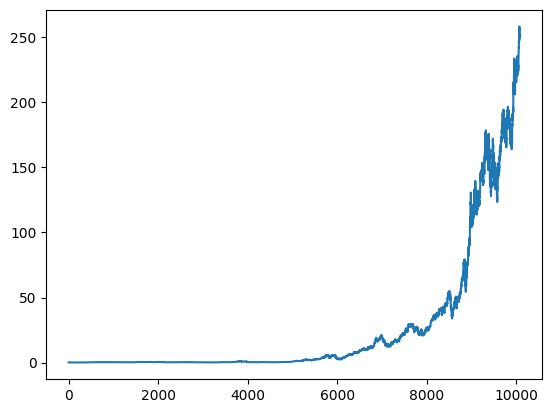

In [7]:
from matplotlib import pyplot as plt

plt.plot(generator.series);

In [8]:
len(generator.series)

10080